In [2]:
%pip install -q ultralytics roboflow pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 136.0 MB/s eta 0:00:00


In [3]:
import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — switch runtime to GPU")

CUDA: True
GPU: Tesla T4


In [4]:
from ultralytics.data.utils import check_det_dataset
check_det_dataset("construction-ppe.yaml")
print("Construction-PPE ready.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset 'construction-ppe.yaml' images not found, missing path '/content/datasets/construction-ppe/images/val'
Unzipping /content/datasets/construction-ppe.zip to /content/datasets/construction-ppe...: 100% ━━━━━━━━━━━━ 2852/2852 1.4Kfiles/s 2.0s
Dataset download success ✅ (3.4s), saved to /content/datasets

Construction-PPE ready.


In [5]:
from roboflow import Roboflow
rf = Roboflow(api_key="EoV98T32NlZoir02bytD")
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
dataset = project.version(1).download("yolov11")   # use the version number shown on the Download page
ROBOFLOW_DIR = dataset.location

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-1 in yolov11:: 100%|██████████| 808/808 [00:00<00:00, 7148.55it/s]


In [6]:
print(ROBOFLOW_DIR)
import os
print(os.listdir(ROBOFLOW_DIR))

/content/Construction-Site-Safety-1
['test', 'README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'valid', 'train']


In [7]:
USE_SH17 = False        # flip to True once SH17 images are in place
SH17_DIR = "/content/datasets/sh17"

if USE_SH17:
    import os
    # Clone repo (labels + yaml + download helper):
    if not os.path.exists("/content/SH17dataset"):
        !git clone https://github.com/ahmadmughees/SH17dataset.git /content/SH17dataset
    print("Follow /content/SH17dataset/README.md to download images, then")
    print(f"arrange them under {SH17_DIR}/images/train + {SH17_DIR}/labels/train")
    print("and place the repo's sh17.yaml at", f"{SH17_DIR}/sh17.yaml")
else:
    print("Skipping SH17.")

Skipping SH17.


In [8]:
%%writefile merge_datasets.py
import argparse
import random
import shutil
from pathlib import Path
import yaml

TARGET_NAMES = {
    0: "helmet", 1: "gloves", 2: "vest", 3: "boots", 4: "goggles",
    5: "none", 6: "Person", 7: "no_helmet", 8: "no_goggle",
    9: "no_gloves", 10: "no_boots", 11: "no_vest",
}

CLASS_MAP = {
    "helmet": 0, "hardhat": 0, "hat": 0,
    "gloves": 1, "glove": 1,
    "vest": 2, "safetyvest": 2, "reflectivevest": 2, "hivisvest": 2,
    "boots": 3, "boot": 3, "shoes": 3, "shoe": 3, "safetyshoes": 3, "foot": 3,
    "goggles": 4, "goggle": 4, "glasses": 4, "safetyglasses": 4,
    "eyewear": 4, "safetygoggles": 4,
    "none": 5, "noppe": 5,
    "person": 6, "worker": 6, "people": 6,
    "nohelmet": 7, "nohardhat": 7, "withouthelmet": 7,
    "nogoggle": 8, "nogoggles": 8, "noglasses": 8,
    "nogloves": 9, "noglove": 9,
    "noboots": 10, "noshoes": 10, "noboot": 10,
    "novest": 11, "nosafetyvest": 11, "noreflectivevest": 11,
}


def normalise(name):
    return name.lower().replace("-", "").replace("_", "").replace(" ", "")


def load_source_names(yaml_path):
    with open(yaml_path) as f:
        data = yaml.safe_load(f)
    names = data["names"]
    if isinstance(names, list):
        names = {i: n for i, n in enumerate(names)}
    return {int(k): v for k, v in names.items()}


def build_remap(source_names, source_label):
    remap, dropped = {}, []
    for idx, name in source_names.items():
        key = normalise(name)
        if key in CLASS_MAP:
            remap[idx] = CLASS_MAP[key]
        else:
            dropped.append(name)
    print(f"[{source_label}] mapped {len(remap)} classes; dropped {len(dropped)}: {dropped}")
    return remap


def find_split_dirs(root):
    for split, aliases in (("train", ["train"]), ("val", ["val", "valid"])):
        for alias in aliases:
            for d in (root / "images" / alias, root / alias / "images"):
                if d.is_dir():
                    yield split, d
                    break
            else:
                continue
            break


def label_dir_for(img_dir):
    parts = [("labels" if p == "images" else p) for p in img_dir.parts]
    return Path(*parts)


def remap_label_file(src_label, dst_label, remap):
    if not src_label.exists():
        return False
    out_lines = []
    for line in src_label.read_text().strip().splitlines():
        parts = line.split()
        if not parts:
            continue
        old_id = int(float(parts[0]))
        if old_id in remap:
            parts[0] = str(remap[old_id])
            out_lines.append(" ".join(parts))
    if not out_lines:
        return False
    dst_label.write_text("\n".join(out_lines) + "\n")
    return True


def process_source(name, root, out_dir, sample_caps, counters):
    root = Path(root)
    yaml_path = next(root.glob("*.yaml"), None) or (root / "data.yaml")
    source_names = load_source_names(yaml_path)
    remap = build_remap(source_names, name)
    cap = sample_caps.get(name)
    for split, img_dir in find_split_dirs(root):
        images = sorted([p for p in img_dir.iterdir()
                         if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}])
        if cap and split == "train" and len(images) > cap:
            random.seed(0)
            images = random.sample(images, cap)
            print(f"[{name}] sampled {cap} train images")
        lbl_dir = label_dir_for(img_dir)
        for img in images:
            src_label = lbl_dir / (img.stem + ".txt")
            stem = f"{name}_{img.stem}"
            dst_img = out_dir / "images" / split / (stem + img.suffix)
            dst_label = out_dir / "labels" / split / (stem + ".txt")
            if remap_label_file(src_label, dst_label, remap):
                shutil.copy(img, dst_img)
                counters[split] = counters.get(split, 0) + 1


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--source", nargs=2, action="append", metavar=("NAME", "ROOT"), required=True)
    ap.add_argument("--out", required=True)
    ap.add_argument("--sample", action="append", default=[])
    args = ap.parse_args()
    sample_caps = {}
    for s in args.sample:
        k, v = s.split("=")
        sample_caps[k] = int(v)
    out_dir = Path(args.out)
    for split in ("train", "val"):
        (out_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (out_dir / "labels" / split).mkdir(parents=True, exist_ok=True)
    counters = {}
    for name, root in args.source:
        print(f"\n=== Processing source: {name} ({root}) ===")
        process_source(name, root, out_dir, sample_caps, counters)
    data_yaml = {
        "path": str(out_dir.resolve()),
        "train": "images/train",
        "val": "images/val",
        "names": TARGET_NAMES,
    }
    with open(out_dir / "data.yaml", "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)
    print("\n=== Merge complete ===")
    print(f"train images: {counters.get('train', 0)}")
    print(f"val images  : {counters.get('val', 0)}")
    print(f"data.yaml   : {out_dir / 'data.yaml'}")


if __name__ == "__main__":
    main()

Writing merge_datasets.py


In [9]:
sources = [
    ["construction", "/content/datasets/construction-ppe"],
    ["roboflow", ROBOFLOW_DIR],
]
if USE_SH17:
    sources.append(["sh17", SH17_DIR])

cmd = "python merge_datasets.py "
for name, root in sources:
    cmd += f'--source {name} "{root}" '
cmd += "--out /content/datasets/merged "
if USE_SH17:
    cmd += "--sample sh17=1500"

print(cmd)
get_ipython().system(cmd)

python merge_datasets.py --source construction "/content/datasets/construction-ppe" --source roboflow "/content/Construction-Site-Safety-1" --out /content/datasets/merged 

=== Processing source: construction (/content/datasets/construction-ppe) ===
[construction] mapped 11 classes; dropped 0: []

=== Processing source: roboflow (/content/Construction-Site-Safety-1) ===
[roboflow] mapped 7 classes; dropped 10: ['Barricade', 'Dumpster', 'EXCAVATORS', 'Mask', 'NO-Mask', 'Safety Net', 'dump truck', 'mini-van', 'truck', 'wheel loader']

=== Merge complete ===
train images: 1264
val images  : 183
data.yaml   : /content/datasets/merged/data.yaml


In [10]:
import glob, yaml
with open("/content/datasets/merged/data.yaml") as f:
    print(yaml.safe_load(f)["names"])
print("train images:", len(glob.glob("/content/datasets/merged/images/train/*")))
print("val images  :", len(glob.glob("/content/datasets/merged/images/val/*")))

{0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots', 11: 'no_vest'}
train images: 1264
val images  : 183


In [11]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")   # small model — more capacity than nano
results = model.train(
    data="/content/datasets/merged/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    name="ppe_merged_s",
    patience=20,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    fliplr=0.5, mosaic=1.0,
    plots=True,
)
save_dir = results.save_dir
print("Saved to:", save_dir)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/merged/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_merged_s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [12]:
m = model.val()
print(f"mAP50-95 : {m.box.map:.4f}")
print(f"mAP50    : {m.box.map50:.4f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,469,824 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1379.6±721.7 MB/s, size: 194.0 KB)
val: Scanning /content/datasets/merged/labels/val.cache... 183 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 183/183 69.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.2it/s 5.5s
                   all        183       1357      0.753       0.44      0.499      0.238
                helmet        141        316      0.708      0.737      0.697      0.338
                gloves         71        141      0.609      0.738      0.734      0.343
                  vest        111        177      0.705      0.718      0.715      0.434
                 boots         67        164      0.791      0.628      0.713      0.407
               goggles         44     

results.png


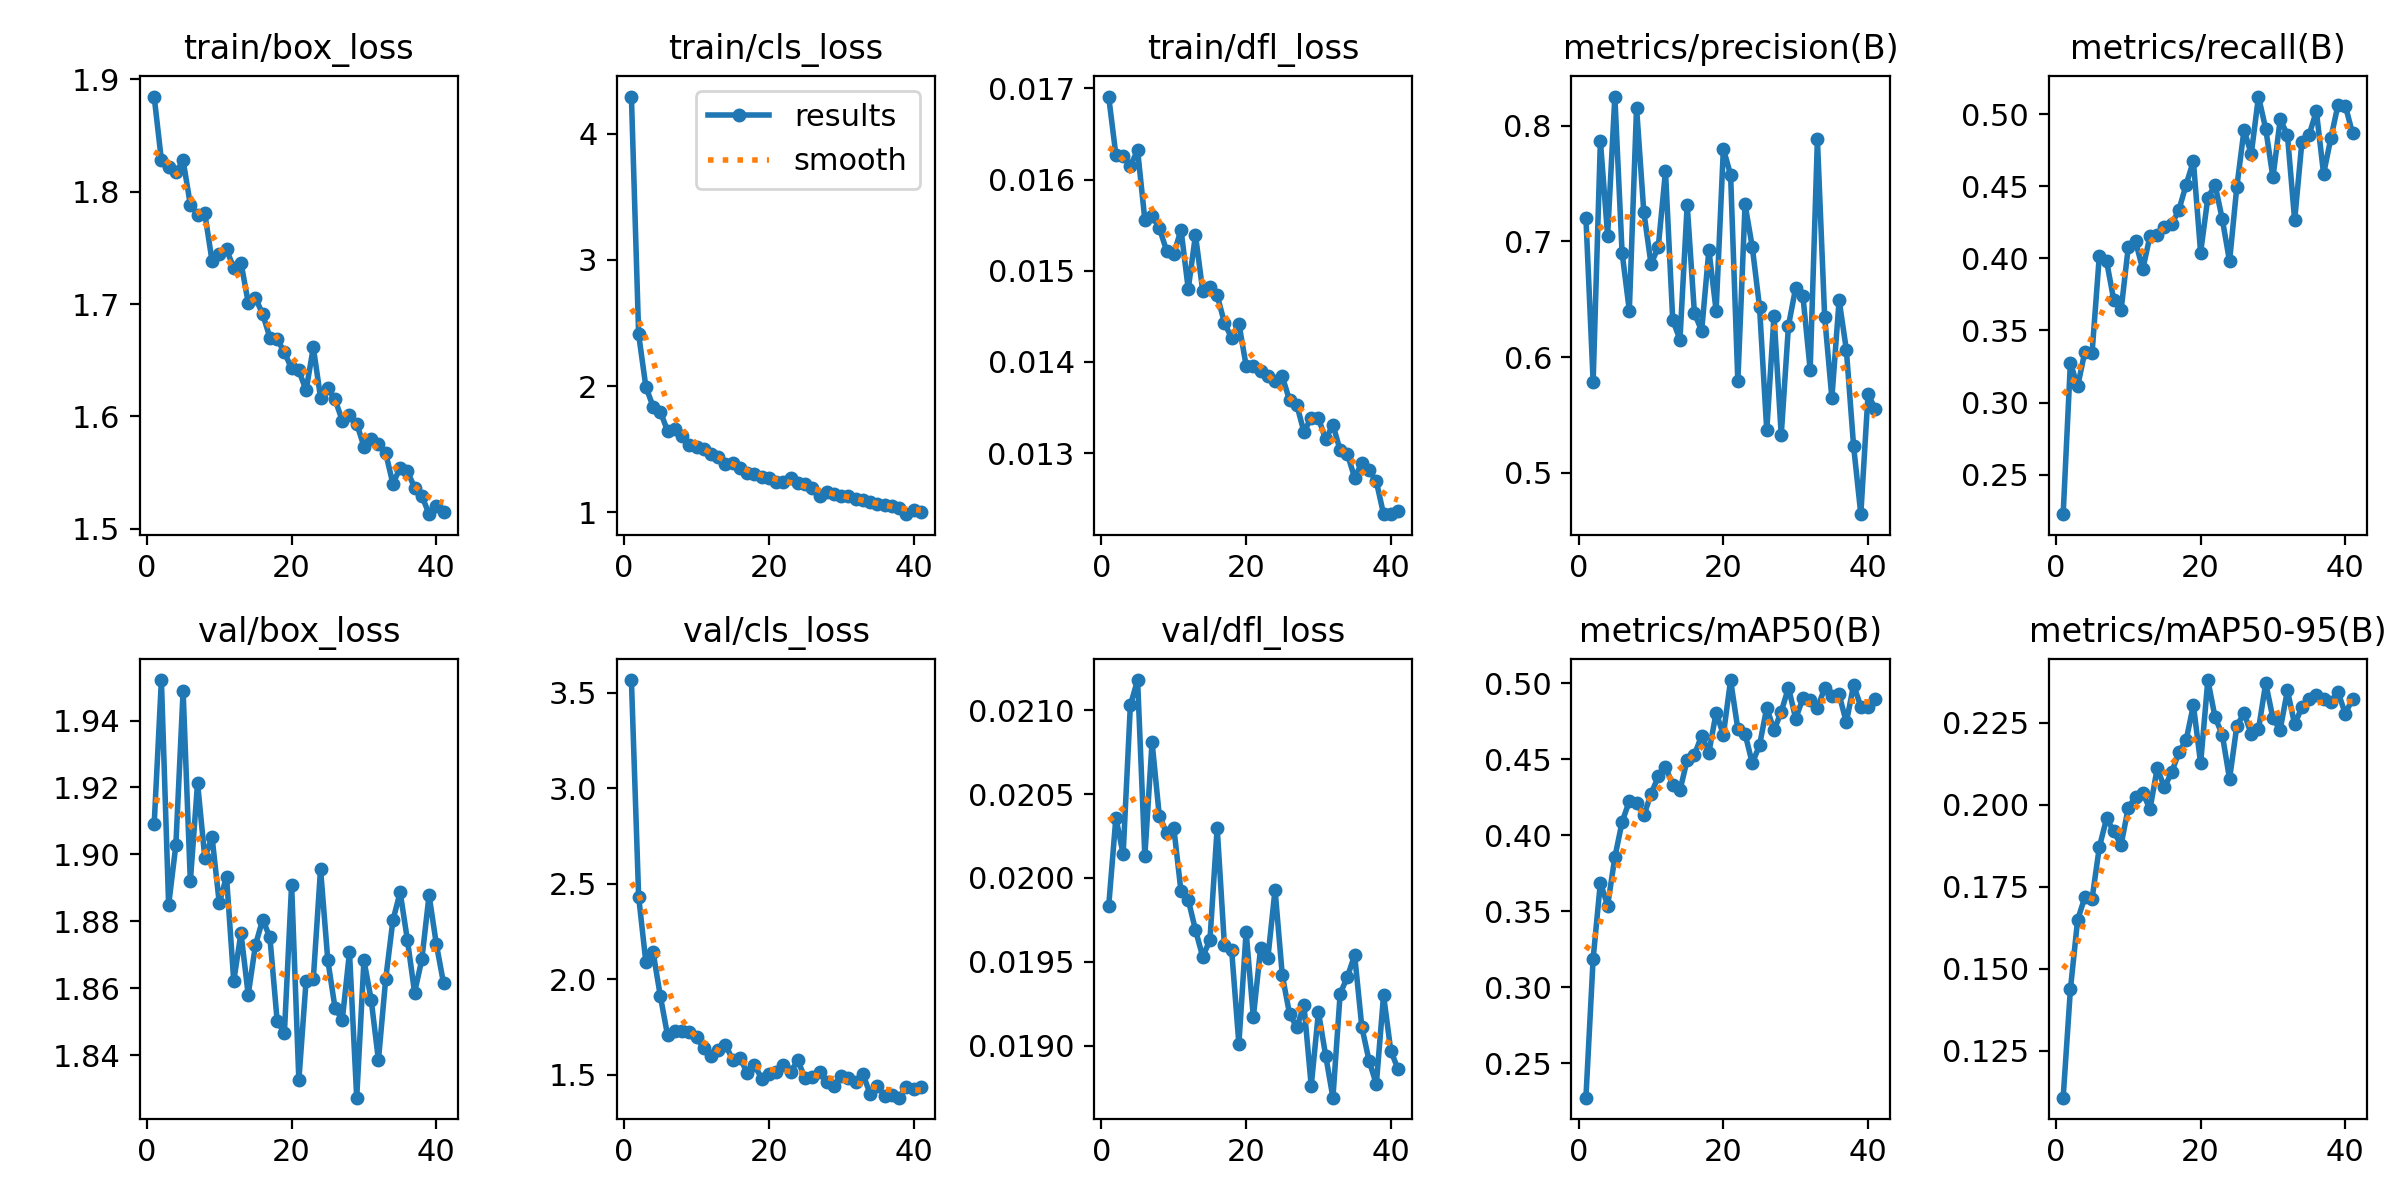

confusion_matrix.png


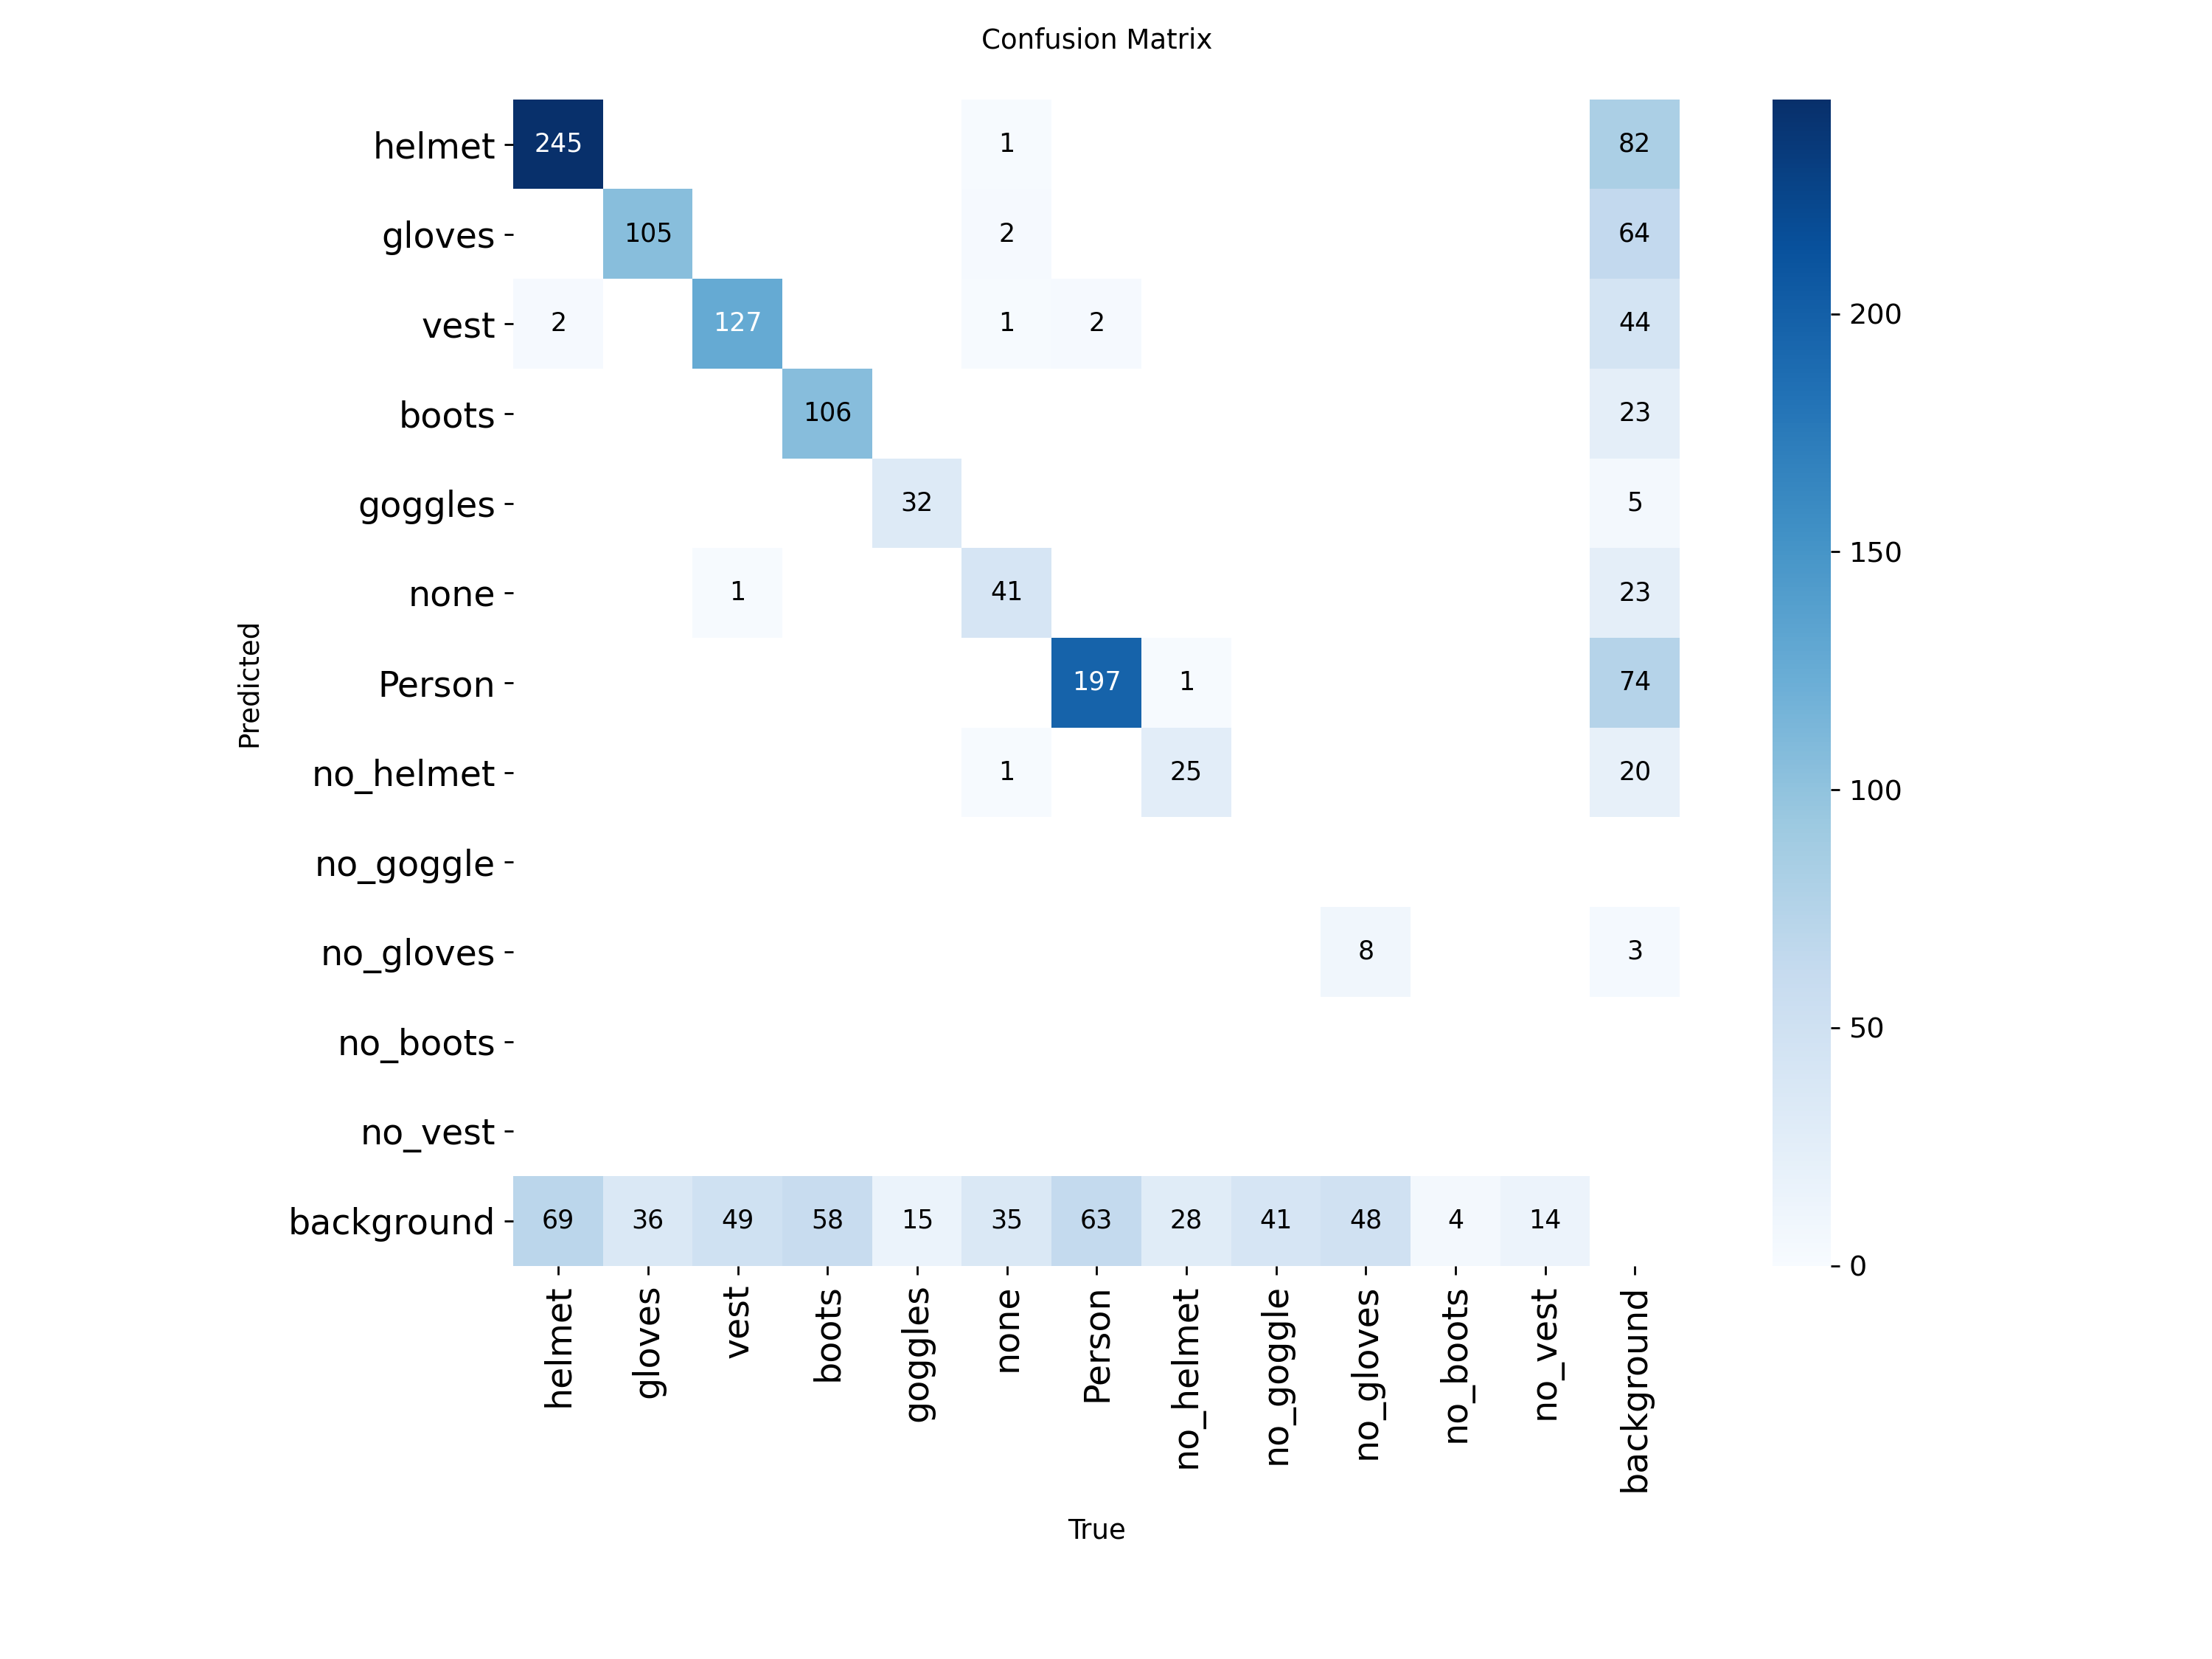

In [13]:
from pathlib import Path
from IPython.display import Image, display
save_dir = Path(save_dir)
for f in ["results.png", "confusion_matrix.png"]:
    p = save_dir / f
    if p.exists():
        print(f); display(Image(filename=str(p), width=720))

## 12. Save best.pt to Google Drive

Don't skip — the session is wiped on disconnect.

In [14]:
best = save_dir / "weights" / "best.pt"


from google.colab import files
files.download(str(best))



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from google.colab import files
files.download(str(save_dir) + "/weights/best.pt")